# Task 3: Basic Level Analysis Questions

# Objective

The objective of this task is to answer the basic analysis questions using the bank employee attrition dataset.

In [1]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load dataset

df = pd.read_csv("bank_employee_attrition.csv")

# Display first 5 records

df.head()

,MMMM_YY,Employee_ID,Age,Gender,City,Education_Level,Department,Income,Date_Of_Joining,LastWorkingDate,Joining_Designation,Grade,Total_Business_Value,Quarterly_Rating,Overtime_Flag
0,Jan-21,10001,29.0,0,BLR,1,Operations,64380.0,17-08-2018,21-08-2021,Analyst,C,11806,2.0,0
1,Feb-21,10001,29.0,0,BLR,1,Operations,64380.0,17-08-2018,21-08-2021,Analyst,C,16644,1.0,0
2,Mar-21,10001,29.0,0,BLR,1,Operations,64380.0,17-08-2018,21-08-2021,Analyst,C,26253,3.0,1
3,Apr-21,10001,29.0,0,BLR,1,Operations,64380.0,17-08-2018,21-08-2021,Analyst,C,-12414,1.0,1
4,May-21,10001,29.0,0,BLR,1,Operations,64380.0,17-08-2018,21-08-2021,Analyst,C,39153,2.0,0


# Q1. What is the total number of rows and columns in the dataset?

In [3]:
# Check number of rows and columns

df.shape

(10816, 15)

In [4]:
# Check data type of each column

df.dtypes

MMMM_YY                  object
Employee_ID               int64
Age                     float64
Gender                    int64
City                     object
Education_Level           int64
Department               object
Income                  float64
Date_Of_Joining          object
LastWorkingDate          object
Joining_Designation      object
Grade                    object
Total_Business_Value      int64
Quarterly_Rating        float64
Overtime_Flag             int64
dtype: object

# Insights

- The dataset contains 15 columns with different data types.
- Both numerical and categorical features are present.
- Date-related columns are stored as object type and may need conversion for analysis.

# Q2. Which columns have missing values?

In [5]:
# Check missing values

missing_values = df.isnull().sum()

missing_values

MMMM_YY                    0
Employee_ID                0
Age                      206
Gender                     0
City                       0
Education_Level            0
Department                 0
Income                   540
Date_Of_Joining            0
LastWorkingDate         9288
Joining_Designation        0
Grade                      0
Total_Business_Value       0
Quarterly_Rating         335
Overtime_Flag              0
dtype: int64

In [6]:
# Calculate missing value percentage

missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage

MMMM_YY                  0.000000
Employee_ID              0.000000
Age                      1.904586
Gender                   0.000000
City                     0.000000
Education_Level          0.000000
Department               0.000000
Income                   4.992604
Date_Of_Joining          0.000000
LastWorkingDate         85.872781
Joining_Designation      0.000000
Grade                    0.000000
Total_Business_Value     0.000000
Quarterly_Rating         3.097263
Overtime_Flag            0.000000
dtype: float64

In [7]:
# Create summary table

missing_summary = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing Percentage': round((df.isnull().sum()/len(df))*100,2)
})

missing_summary

,Missing Count,Missing Percentage
MMMM_YY,0,0.00
Employee_ID,0,0.00
Age,206,1.90
Gender,0,0.00
City,0,0.00
Education_Level,0,0.00
Department,0,0.00
Income,540,4.99
Date_Of_Joining,0,0.00
LastWorkingDate,9288,85.87


# Insights

- Missing values are present in Age, Income, Quarterly_Rating and LastWorkingDate.
- LastWorkingDate null values may indicate active employees.
- LastWorkingDate has the highest percentage of missing values.

# Q3. Mean, Median and Standard Deviation

In [9]:
# Calculate statistics

stats = df[
    ['Age',
     'Income',
     'Total_Business_Value',
     'Quarterly_Rating']
].agg(['mean','median','std'])

stats

,Age,Income,Total_Business_Value,Quarterly_Rating
mean,38.772290,55969.390911,69318.365200,2.686480
median,39.000000,55915.000000,55308.500000,3.000000
std,9.848441,16879.821090,62353.496693,0.940692


# Insights

- Income shows high variation among employees (high standard deviation).
- The average and median age are close, indicating a fairly balanced age distribution.
- Total_Business_Value has the highest variability, suggesting significant differences in employee performance.

# Q4. Unique Employees and Gender Distribution

In [10]:
# Count unique employees

df['Employee_ID'].nunique()

500

In [11]:
# Count male and female employees

df['Gender'].replace({
    0:'Male',
    1:'Female'
}).value_counts()

Gender
Male      6763
Female    4053
Name: count, dtype: int64

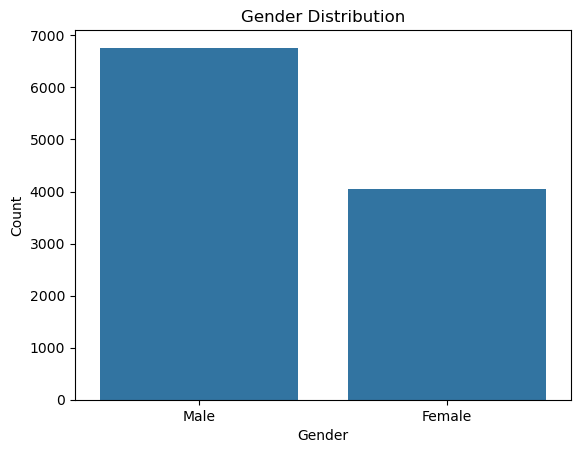

In [12]:
# Plot gender distribution

sns.countplot(
    x=df['Gender'].replace({
        0:'Male',
        1:'Female'
    })
)

plt.title("Gender Distribution")

plt.xlabel("Gender")

plt.ylabel("Count")

plt.show()

# Insights

- The dataset contains 500 unique employees.
- Male employees (6763 records) outnumber female employees (4053 records).
- The workforce is male-dominated based on the available records.

# Q5. How many employees joined and left the bank?

In [17]:
# Count employees joined

df['Employee_ID'].nunique()

500

In [18]:
# Count unique employees who left

df[df['LastWorkingDate'].notnull()]['Employee_ID'].nunique()

113

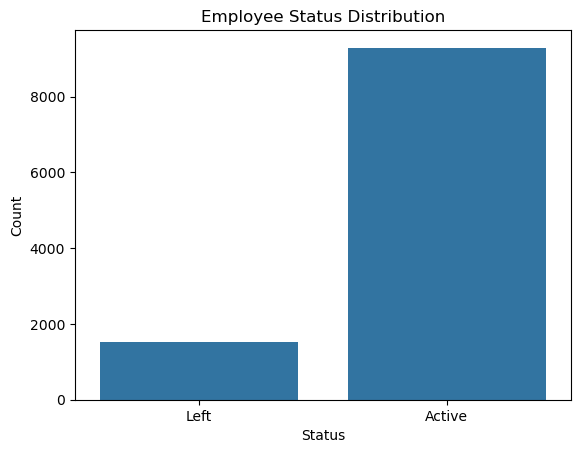

In [19]:
# Create attrition flag

df['Attrition'] = np.where(
    df['LastWorkingDate'].notnull(),
    'Left',
    'Active'
)

# Plot attrition distribution

sns.countplot(
    x='Attrition',
    data=df
)

plt.title("Employee Status Distribution")

plt.xlabel("Status")

plt.ylabel("Count")

plt.show()

# Insights

- Total joined employees = 500.
- Total employees who left = 113.
- Most employees remained active during the period, indicating a relatively low attrition rate.

# Conclusion

- Dataset structure and data types were examined.
- Missing values and their percentages were identified.
- Key statistical measures were analyzed.
- Employee and gender distributions were explored.
- Employee joining and attrition trends were evaluated.